# Análisis descriptivo del shock CERA

Este notebook explora el shock exógeno de depósitos vía el Régimen de Regularización de Activos (Ley 27.743, "blanqueo 2024") antes de cualquier regresión. El objetivo es (a) verificar que la magnitud y la forma del shock son las que esperamos, (b) ver cómo se distribuyó entre entidades, y (c) identificar potenciales problemas de identificación para los pasos de análisis subsiguientes.

Secciones:

1. **Datos y convenciones** — carga de panel, tipo de cambio, definición de cuentas CERA.
2. **Magnitud agregada del shock** — cuánto entró al sistema, composición por moneda y residencia, tamaño relativo al stock preexistente de depósitos USD.
3. **Distribución entre entidades** — qué bancos recibieron el flujo, concentración del shock, y relación con el tamaño preexistente del banco en USD.

Notas metodológicas referenciadas: `docs/notas/cera_regimen.md` (régimen CERA), `docs/notas/metodologia_paneles.md §3.6.bis` (convención de signos del balance).

# Datos y convenciones

Tres advertencias importantes que se aplican a todas las queries que siguen:

- Los saldos del panel de balance respetan **convención contable BCRA**. Los pasivos (como CERA, que son depósitos) tienen signo **negativo**. Tomamos `abs(saldo)` cuando queremos magnitud económica.
- Los saldos en cuentas en moneda extranjera están expresados en **pesos convertidos al tipo de cambio contable** (aproximadamente el A-3500 de fin de mes). Para leer en USD hay que dividir por el TC de la fecha.
- Las cuatro cuentas CERA son `311793` (pesos residentes país), `312183` (pesos residentes exterior), `315794` (USD residentes país, **dominante**) y `316147` (USD residentes exterior).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "utils"))
from paths import PANELES, DIMENSIONES, EXTERNAL, RAW, REPO

import json
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import numpy as np

pd.options.display.float_format = "{:,.2f}".format
plt.rcParams.update({"figure.figsize": (10, 4.5), "figure.dpi": 100})

PANEL_BAL = PANELES / "panel_balance_mensual_proforma.parquet"  # pro-forma por default: consolida Macro+BMA y Galicia+HSBC
DIM_ENT = DIMENSIONES / "dim_entidades.parquet"
CW_CUENTA = EXTERNAL / "crosswalks/cuenta_categoria.csv"
FX_JSON = RAW / "bcra_api/005_tc_mayorista_a3500.json"

CERA_CUENTAS = ("311793", "312183", "315794", "316147")
CERA_CUENTAS_USD = ("315794", "316147")
CERA_CUENTAS_ARS = ("311793", "312183")

## Tipo de cambio A-3500 a fin de mes

Lo armamos una sola vez al inicio para usarlo en todas las conversiones a USD.

In [2]:
with open(FX_JSON) as f:
    fx_raw = json.load(f)

fx = pd.DataFrame(fx_raw["results"][0]["detalle"])
fx["fecha"] = pd.to_datetime(fx["fecha"])
fx["yyyymm"] = fx["fecha"].dt.strftime("%Y%m").astype(int)
fx_eom = (fx.sort_values("fecha")
            .groupby("yyyymm", as_index=False)
            .tail(1)
            .reset_index(drop=True)
            [["yyyymm", "valor"]]
            .rename(columns={"valor": "tc_a3500"}))

print(f"TC A-3500 disponible: {fx_eom.yyyymm.min()} - {fx_eom.yyyymm.max()}, {len(fx_eom)} meses")
fx_eom.tail(6)

TC A-3500 disponible: 201501 - 202604, 136 meses


,yyyymm,tc_a3500
130,202511,"1,450.75"
131,202512,"1,459.42"
132,202601,"1,447.67"
133,202602,"1,408.97"
134,202603,"1,382.76"
135,202604,"1,387.70"


# Magnitud agregada del shock

## Evolución mensual del saldo CERA total

Serie de tiempo del saldo agregado de las cuatro cuentas CERA, sumado sobre todo el sistema. Se expresa en billones de pesos y en miles de millones de USD (convertido al A-3500 de fin de mes).

In [3]:
cera_mensual = duckdb.sql(f"""
    select yyyymm,
           abs(sum(saldo)) as saldo_ars,
           count(distinct codigo_entidad) filter (where saldo != 0) as bancos_con_saldo
    from '{PANEL_BAL}'
    where codigo_cuenta in {CERA_CUENTAS}
    group by yyyymm
    order by yyyymm
""").df()

cera_mensual = cera_mensual.merge(fx_eom, on="yyyymm", how="left")
cera_mensual["saldo_billones_ars"] = cera_mensual["saldo_ars"] / 1e12
cera_mensual["saldo_miles_millones_usd"] = cera_mensual["saldo_ars"] / cera_mensual["tc_a3500"] / 1e9
cera_mensual["fecha"] = pd.to_datetime(cera_mensual["yyyymm"].astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)

# muestro las observaciones desde jun-2024 (un mes antes del inicio del régimen)
cera_mensual[cera_mensual.yyyymm >= 202406][["yyyymm", "bancos_con_saldo", "saldo_billones_ars", "saldo_miles_millones_usd"]]

,yyyymm,bancos_con_saldo,saldo_billones_ars,saldo_miles_millones_usd
0,202407,4,0.00,0.00
1,202408,26,0.54,0.57
2,202409,42,11.74,12.09
3,202410,44,12.18,12.30
4,202411,39,7.84,7.75
5,202412,38,6.02,5.83
6,202501,38,5.30,5.03
7,202502,38,4.78,4.49
8,202503,38,4.29,4.00
9,202504,38,4.19,3.58


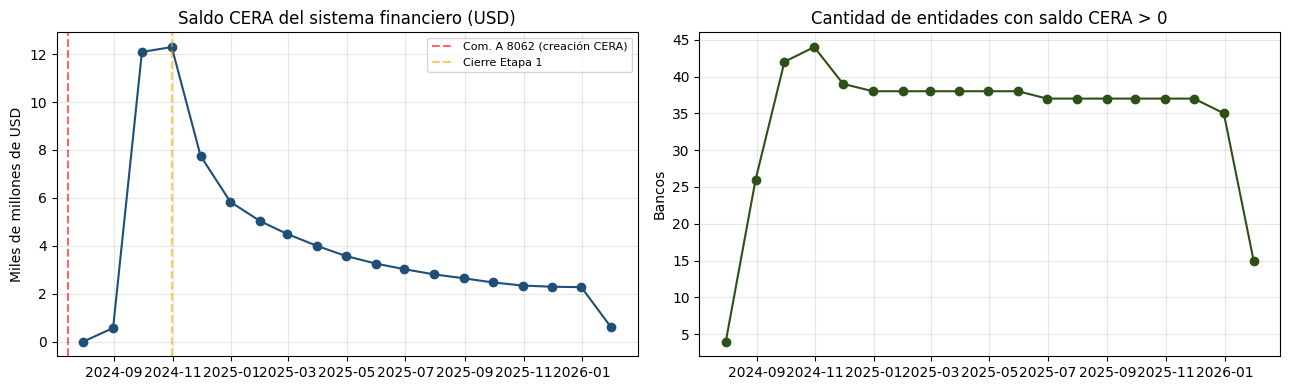

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
serie = cera_mensual[cera_mensual.yyyymm >= 202406]

ax1.plot(serie.fecha, serie.saldo_miles_millones_usd, marker="o", color="#1f4e79")
ax1.set_title("Saldo CERA del sistema financiero (USD)")
ax1.set_ylabel("Miles de millones de USD")
ax1.grid(alpha=0.3)
ax1.axvline(pd.Timestamp("2024-07-15"), ls="--", color="red", alpha=0.6, label="Com. A 8062 (creación CERA)")
ax1.axvline(pd.Timestamp("2024-10-31"), ls="--", color="orange", alpha=0.6, label="Cierre Etapa 1")
ax1.legend(loc="upper right", fontsize=8)

ax2.plot(serie.fecha, serie.bancos_con_saldo, marker="o", color="#2d5016")
ax2.set_title("Cantidad de entidades con saldo CERA > 0")
ax2.set_ylabel("Bancos")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Composición por cuenta

Las cuatro cuentas CERA corresponden a cuatro combinaciones `{moneda} × {residencia del titular}`. La hipótesis previa es que la cuenta `315794` (USD, residentes del país) concentra casi todo el flujo, porque el blanqueo apuntó principalmente a residentes argentinos con tenencias no declaradas en dólares.

In [5]:
cera_por_cuenta = duckdb.sql(f"""
    select yyyymm, codigo_cuenta,
           abs(sum(saldo)) / 1e12 as saldo_billones_ars
    from '{PANEL_BAL}'
    where codigo_cuenta in {CERA_CUENTAS}
    group by yyyymm, codigo_cuenta
    order by yyyymm, codigo_cuenta
""").df()

pivot = cera_por_cuenta.pivot(index="yyyymm", columns="codigo_cuenta", values="saldo_billones_ars").fillna(0)
pivot.columns = [f"{c} ({desc})" for c, desc in zip(pivot.columns, [
    "ARS residentes país", "ARS residentes exterior", "USD residentes país", "USD residentes exterior"
])]
pivot = pivot[pivot.index >= 202406]
pivot

,311793 (ARS residentes país),312183 (ARS residentes exterior),315794 (USD residentes país),316147 (USD residentes exterior)
yyyymm,,,,
202407,0.00,0.00,0.00,0.00
202408,0.02,0.00,0.52,0.00
202409,0.38,0.00,11.36,0.00
202410,0.41,0.00,11.77,0.00
202411,0.09,0.00,7.76,0.00
202412,0.05,0.00,5.98,0.00
202501,0.03,0.00,5.27,0.00
202502,0.02,0.00,4.76,0.00
202503,0.03,0.00,4.27,0.00


In [6]:
# Participación porcentual de cada cuenta sobre el total en el peak
peak = pivot.loc[pivot.sum(axis=1).idxmax()]
participaciones = (peak / peak.sum() * 100).round(2)
print(f"Mes peak: {pivot.sum(axis=1).idxmax()}")
print("Participación de cada cuenta en el saldo total del mes peak (%):")
participaciones

Mes peak: 202410
Participación de cada cuenta en el saldo total del mes peak (%):


311793 (ARS residentes país)        3.37
312183 (ARS residentes exterior)    0.00
315794 (USD residentes país)       96.63
316147 (USD residentes exterior)    0.00
Name: 202410, dtype: float64

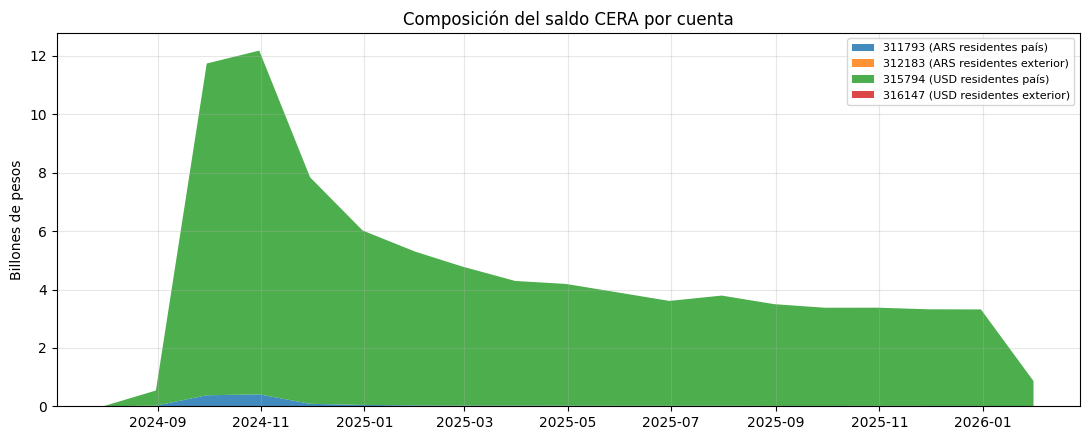

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5))
fechas = pd.to_datetime(pivot.index.astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
ax.stackplot(fechas, pivot.T.values, labels=pivot.columns, alpha=0.85)
ax.set_title("Composición del saldo CERA por cuenta")
ax.set_ylabel("Billones de pesos")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Tamaño relativo al stock preexistente de depósitos USD

Para dimensionar, comparamos el saldo CERA contra el total de depósitos en moneda extranjera del sector privado no financiero (capítulos 315 y 316, que incluyen todos los depósitos ME residentes país + exterior). El ratio muestra qué fracción de los depósitos USD corresponde específicamente a CERA en cada mes.

In [8]:
ratio_cera = duckdb.sql(f"""
    with cera as (
        select yyyymm, abs(sum(saldo)) as cera_ars
        from '{PANEL_BAL}'
        where codigo_cuenta in {CERA_CUENTAS_USD}
        group by yyyymm
    ),
    depositos_usd as (
        select yyyymm, abs(sum(saldo)) as depositos_usd_ars
        from '{PANEL_BAL}'
        where codigo_cuenta like '315%' or codigo_cuenta like '316%'
        group by yyyymm
    )
    select d.yyyymm,
           d.depositos_usd_ars / 1e12 as depositos_usd_billones,
           coalesce(c.cera_ars, 0) / 1e12 as cera_usd_billones,
           coalesce(c.cera_ars, 0) / d.depositos_usd_ars as ratio_cera_sobre_depositos_usd
    from depositos_usd d
    left join cera c using (yyyymm)
    where d.yyyymm >= 202401
    order by d.yyyymm
""").df()

ratio_cera

,yyyymm,depositos_usd_billones,cera_usd_billones,ratio_cera_sobre_depositos_usd
0,202401,15.54,0.00,0.00
1,202402,15.76,0.00,0.00
2,202403,16.44,0.00,0.00
3,202404,17.06,0.00,0.00
4,202405,17.70,0.00,0.00
5,202406,18.22,0.00,0.00
6,202407,19.72,0.00,0.00
7,202408,20.70,0.52,0.03
8,202409,32.79,11.36,0.35
9,202410,36.65,11.77,0.32


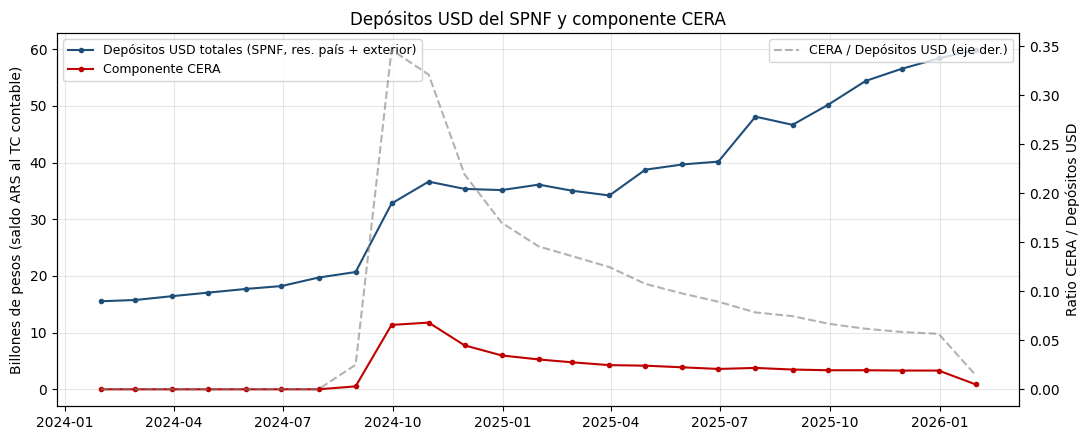

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
fechas = pd.to_datetime(ratio_cera.yyyymm.astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)

ax.plot(fechas, ratio_cera.depositos_usd_billones, label="Depósitos USD totales (SPNF, res. país + exterior)", color="#1f4e79", marker="o", ms=3)
ax.plot(fechas, ratio_cera.cera_usd_billones, label="Componente CERA", color="#c00000", marker="o", ms=3)
ax.set_title("Depósitos USD del SPNF y componente CERA")
ax.set_ylabel("Billones de pesos (saldo ARS al TC contable)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)

ax2 = ax.twinx()
ax2.plot(fechas, ratio_cera.ratio_cera_sobre_depositos_usd, color="gray", ls="--", alpha=0.6, label="CERA / Depósitos USD (eje der.)")
ax2.set_ylabel("Ratio CERA / Depósitos USD")
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

## Persistencia: CERA se transforma en depósitos USD regulares

Hipótesis: el saldo específico de las cuatro cuentas CERA cae después del peak (oct-2024), pero los fondos no salen del sistema — se reclasifican dentro del mismo balance bancario a cuentas USD "normales" del capítulo 315 + 316 (cajas de ahorro ME, cuentas corrientes ME, plazos fijos ME).

Verificación: comparamos la caída del saldo CERA con la evolución del resto de depósitos USD (total 315+316 menos CERA).

In [10]:
persistencia = duckdb.sql(f"""
    with t as (
        select yyyymm,
               abs(sum(case when codigo_cuenta in {CERA_CUENTAS_USD} then saldo else 0 end)) as cera_usd,
               abs(sum(case when (codigo_cuenta like '315%' or codigo_cuenta like '316%')
                             and codigo_cuenta not in {CERA_CUENTAS} then saldo else 0 end)) as resto_usd,
               abs(sum(case when codigo_cuenta like '315%' or codigo_cuenta like '316%' then saldo else 0 end)) as total_usd
        from '{PANEL_BAL}'
        group by yyyymm
    )
    select * from t where yyyymm >= 202401 order by yyyymm
""").df()

persistencia = persistencia.merge(fx_eom, on="yyyymm", how="left")
for col in ["cera_usd", "resto_usd", "total_usd"]:
    persistencia[col.replace("_usd", "_miles_mill_usd")] = persistencia[col] / persistencia["tc_a3500"] / 1e9

persistencia[["yyyymm", "cera_miles_mill_usd", "resto_miles_mill_usd", "total_miles_mill_usd"]].round(2)

,yyyymm,cera_miles_mill_usd,resto_miles_mill_usd,total_miles_mill_usd
0,202401,0.00,18.80,18.80
1,202402,0.00,18.71,18.71
2,202403,0.00,19.18,19.18
3,202404,0.00,19.46,19.46
4,202405,0.00,19.78,19.78
5,202406,0.00,19.98,19.98
6,202407,0.00,21.14,21.14
7,202408,0.54,21.18,21.72
8,202409,11.70,22.07,33.77
9,202410,11.88,25.11,36.99


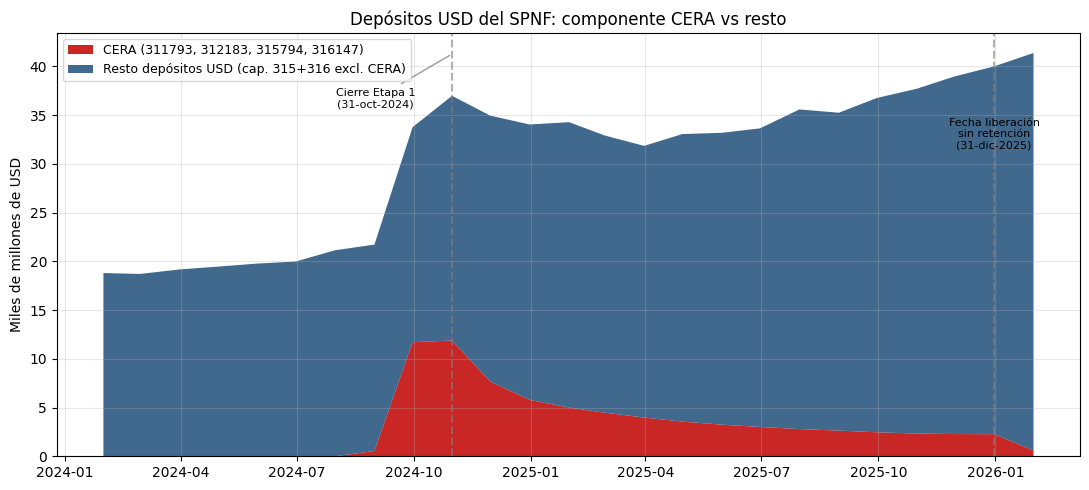

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
fechas = pd.to_datetime(persistencia.yyyymm.astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)

ax.stackplot(fechas,
             persistencia.cera_miles_mill_usd,
             persistencia.resto_miles_mill_usd,
             labels=["CERA (311793, 312183, 315794, 316147)", "Resto depósitos USD (cap. 315+316 excl. CERA)"],
             colors=["#c00000", "#1f4e79"], alpha=0.85)
ax.set_title("Depósitos USD del SPNF: componente CERA vs resto")
ax.set_ylabel("Miles de millones de USD")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
ax.axvline(pd.Timestamp("2024-10-31"), ls="--", color="gray", alpha=0.6)
ax.axvline(pd.Timestamp("2025-12-31"), ls="--", color="gray", alpha=0.6)
ax.annotate("Cierre Etapa 1\n(31-oct-2024)", (pd.Timestamp("2024-10-31"), ax.get_ylim()[1]*0.95),
            fontsize=8, ha="center", va="top", xytext=(pd.Timestamp("2024-09-01"), ax.get_ylim()[1]*0.87),
            arrowprops=dict(arrowstyle="-", alpha=0.4))
ax.annotate("Fecha liberación\nsin retención\n(31-dic-2025)", (pd.Timestamp("2025-12-31"), ax.get_ylim()[1]*0.80),
            fontsize=8, ha="center", va="top")

plt.tight_layout()
plt.show()

Observación: mientras CERA baja desde el peak hacia cero entre oct-2024 y ene-2026, el **resto de depósitos USD** sigue creciendo. El **total de depósitos USD del sistema** pasó de USD ~20B pre-shock a USD ~41B en ene-2026 — se duplicó. La plata se quedó en el sistema, cambió de cuenta interna.

**Implicancia conceptual**: para los bancos, el shock relevante no es "CERA peak" sino **"aumento de depósitos USD por encima de la tendencia pre-shock"**. Esta diferencia es central para definir el tratamiento en las regresiones.

# Distribución entre entidades

## Ranking de entidades por saldo CERA peak

Primera pregunta para la identificación: ¿qué bancos captaron el shock? La concentración importa. Si tres bancos concentran el 80%+ del flujo, la variación cross-section es débil y la estrategia econométrica se complica.

In [12]:
ranking = duckdb.sql(f"""
    with por_mes as (
        select codigo_entidad, yyyymm, abs(sum(saldo)) as saldo_mes
        from '{PANEL_BAL}'
        where codigo_cuenta in {CERA_CUENTAS}
        group by codigo_entidad, yyyymm
    ),
    peaks as (
        select codigo_entidad, max(saldo_mes) as saldo_peak,
               arg_max(yyyymm, saldo_mes) as mes_peak
        from por_mes
        where saldo_mes > 0
        group by codigo_entidad
    )
    select p.codigo_entidad, e.nombre, e.sigla, p.mes_peak,
           p.saldo_peak / 1e9 as saldo_peak_miles_millones_ars
    from peaks p
    left join '{DIM_ENT}' e on p.codigo_entidad = e.codigo_entidad and e.es_vigente
    order by p.saldo_peak desc
""").df()

# convierto el saldo peak a USD usando el TC del mes del peak de cada banco
ranking = ranking.merge(fx_eom.rename(columns={"yyyymm": "mes_peak"}), on="mes_peak", how="left")
ranking["saldo_peak_miles_millones_usd"] = ranking["saldo_peak_miles_millones_ars"] * 1000 / ranking["tc_a3500"] / 1000

print(f"Entidades con saldo CERA alguna vez > 0: {len(ranking)}")
ranking.head(20)

Entidades con saldo CERA alguna vez > 0: 45


,codigo_entidad,nombre,sigla,mes_peak,saldo_peak_miles_millones_ars,tc_a3500,saldo_peak_miles_millones_usd
0,00007,Banco de Galicia y Buenos Aires S.A.,GALICIA,202410,"2,952.79",990.75,2.98
1,00072,Banco Santander Argentina S.A.,SANTAND,202410,"2,717.56",990.75,2.74
2,00017,Banco BBVA Argentina S.A.,BBVA.AR,202410,"1,456.48",990.75,1.47
3,00285,Banco Macro S.A.,MACRO,202409,"1,445.48",970.92,1.49
4,00011,Banco de la Nación Argentina,NACION,202410,861.78,990.75,0.87
5,00014,Banco de la Provincia de Buenos Aires,PRBSAS,202410,454.54,990.75,0.46
6,00015,Industrial and Commercial Bank of China (Argen...,INDUSTR,202409,429.13,970.92,0.44
7,00191,Banco Credicoop Cooperativo Limitado,CREDICO,202410,408.96,990.75,0.41
8,00034,Banco Patagonia S.A.,PATAGON,202409,293.61,970.92,0.30
9,00027,Banco Supervielle S.A.,SUPERVI,202410,290.89,990.75,0.29


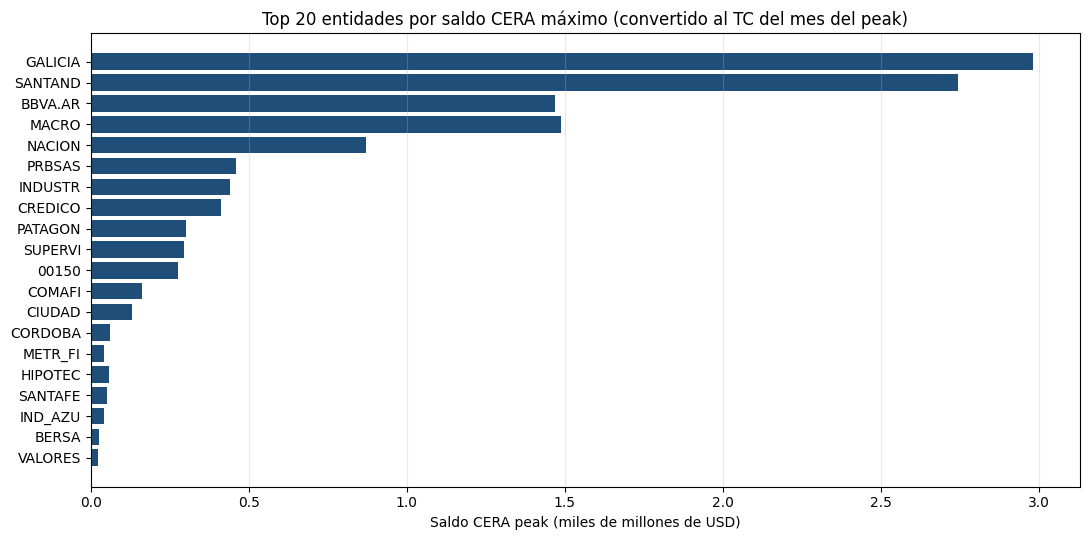

In [13]:
fig, ax = plt.subplots(figsize=(11, 5.5))
top = ranking.head(20).copy()
labels = top["sigla"].fillna(top["codigo_entidad"]).str[:12]
ax.barh(range(len(top)), top["saldo_peak_miles_millones_usd"], color="#1f4e79")
ax.set_yticks(range(len(top)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Saldo CERA peak (miles de millones de USD)")
ax.set_title("Top 20 entidades por saldo CERA máximo (convertido al TC del mes del peak)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Medidas de concentración

Calculamos el índice Herfindahl-Hirschman (HHI) y las participaciones acumuladas top-k a partir de los saldos CERA por banco en el mes del pico del sistema.

In [14]:
mes_peak_sistema = int(cera_mensual.loc[cera_mensual.saldo_ars.idxmax(), "yyyymm"])
print(f"Mes peak del sistema: {mes_peak_sistema}")

shares = duckdb.sql(f"""
    with saldos as (
        select codigo_entidad, abs(sum(saldo)) as saldo
        from '{PANEL_BAL}'
        where codigo_cuenta in {CERA_CUENTAS}
          and yyyymm = {mes_peak_sistema}
        group by codigo_entidad
        having saldo > 0
    )
    select codigo_entidad, saldo,
           saldo / (select sum(saldo) from saldos) as share
    from saldos
    order by saldo desc
""").df()

shares = shares.merge(
    duckdb.sql(f"select codigo_entidad, nombre, sigla from '{DIM_ENT}' where es_vigente").df(),
    on="codigo_entidad", how="left"
)

hhi = (shares["share"] ** 2).sum() * 10000  # HHI estándar sobre 10.000
share_top3 = shares.head(3)["share"].sum()
share_top5 = shares.head(5)["share"].sum()
share_top10 = shares.head(10)["share"].sum()

print(f"\nConcentración en el mes peak ({mes_peak_sistema}):")
print(f"  HHI:           {hhi:>8,.0f}   (interpretación: <1500 bajo, 1500-2500 moderado, >2500 alto)")
print(f"  Share top-3:   {share_top3:>8.1%}")
print(f"  Share top-5:   {share_top5:>8.1%}")
print(f"  Share top-10:  {share_top10:>8.1%}")
print(f"  Total bancos con saldo: {len(shares)}")

shares.head(10)[["codigo_entidad", "sigla", "nombre", "saldo", "share"]]

Mes peak del sistema: 202410

Concentración en el mes peak (202410):
  HHI:              1,462   (interpretación: <1500 bajo, 1500-2500 moderado, >2500 alto)
  Share top-3:      58.5%
  Share top-5:      76.9%
  Share top-10:     92.0%
  Total bancos con saldo: 44


,codigo_entidad,sigla,nombre,saldo,share
0,00007,GALICIA,Banco de Galicia y Buenos Aires S.A.,"2,952,786,967,000.00",0.24
1,00072,SANTAND,Banco Santander Argentina S.A.,"2,717,555,033,000.00",0.22
2,00017,BBVA.AR,Banco BBVA Argentina S.A.,"1,456,484,375,000.00",0.12
3,00285,MACRO,Banco Macro S.A.,"1,380,585,070,000.00",0.11
4,00011,NACION,Banco de la Nación Argentina,"861,781,610,000.00",0.07
5,00014,PRBSAS,Banco de la Provincia de Buenos Aires,"454,537,071,000.00",0.04
6,00015,INDUSTR,Industrial and Commercial Bank of China (Argen...,"414,109,037,000.00",0.03
7,00191,CREDICO,Banco Credicoop Cooperativo Limitado,"408,958,882,000.00",0.03
8,00027,SUPERVI,Banco Supervielle S.A.,"290,887,154,000.00",0.02
9,00150,NaN,NaN,"272,930,299,000.00",0.02


## Relación entre tamaño preexistente y CERA recibida

La clave para la estrategia shift-share: ¿los bancos más grandes en depósitos USD antes del blanqueo son los mismos que recibieron más flujo? Un mapeo 1-a-1 significa que el shock es proporcional al tamaño, lo cual es consistente con que los depositantes eligieron bancos con los que ya tenían relación. Una dispersión alta en torno a la diagonal indicaría que el shock tiene un componente idiosincrático — potencialmente explotable.

In [15]:
# Share pre-shock: junio 2024, sobre depósitos USD totales (capítulos 315+316)
# Share CERA: sobre saldo CERA total en el mes peak
PRE_YYYYMM = 202406

pre_shares = duckdb.sql(f"""
    with dep_usd_pre as (
        select codigo_entidad, abs(sum(saldo)) as dep_usd_pre
        from '{PANEL_BAL}'
        where (codigo_cuenta like '315%' or codigo_cuenta like '316%')
          and yyyymm = {PRE_YYYYMM}
        group by codigo_entidad
        having dep_usd_pre > 0
    )
    select codigo_entidad, dep_usd_pre,
           dep_usd_pre / (select sum(dep_usd_pre) from dep_usd_pre) as share_pre
    from dep_usd_pre
""").df()

comparacion = shares[["codigo_entidad", "sigla", "saldo", "share"]].rename(columns={"share": "share_cera", "saldo": "saldo_cera"})
comparacion = comparacion.merge(pre_shares, on="codigo_entidad", how="outer").fillna(0)
comparacion = comparacion.sort_values("share_cera", ascending=False)
comparacion.head(15)

,codigo_entidad,sigla,saldo_cera,share_cera,dep_usd_pre,share_pre
0,00007,GALICIA,"2,952,786,967,000.00",0.24,"2,547,652,093,000.00",0.14
13,00072,SANTAND,"2,717,555,033,000.00",0.22,"2,546,930,714,000.00",0.14
5,00017,BBVA.AR,"1,456,484,375,000.00",0.12,"1,719,832,707,000.00",0.09
32,00285,MACRO,"1,380,585,070,000.00",0.11,"1,270,767,053,000.00",0.07
1,00011,NACION,"861,781,610,000.00",0.07,"2,765,443,152,000.00",0.15
2,00014,PRBSAS,"454,537,071,000.00",0.04,"1,299,161,883,000.00",0.07
3,00015,INDUSTR,"414,109,037,000.00",0.03,"698,784,139,000.00",0.04
23,00191,CREDICO,"408,958,882,000.00",0.03,"446,697,087,000.00",0.02
7,00027,SUPERVI,"290,887,154,000.00",0.02,"342,791,243,000.00",0.02
22,00150,0,"272,930,299,000.00",0.02,"827,975,834,000.00",0.05


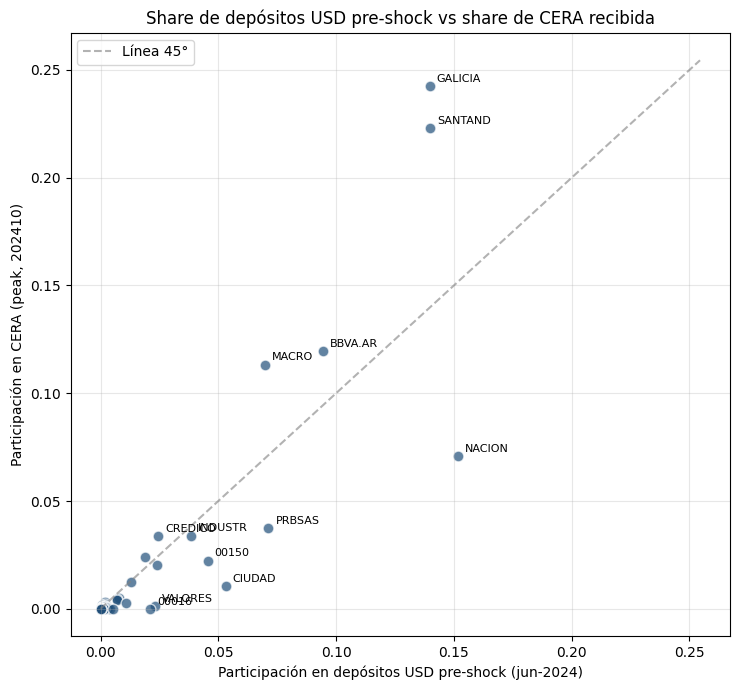

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 7))
x = comparacion["share_pre"]
y = comparacion["share_cera"]

ax.scatter(x, y, s=60, alpha=0.7, color="#1f4e79", edgecolor="white")
# Línea 45°
max_v = max(x.max(), y.max()) * 1.05
ax.plot([0, max_v], [0, max_v], ls="--", color="gray", alpha=0.6, label="Línea 45°")

# Etiquetas a los que están lejos de la diagonal o son muy grandes
for _, row in comparacion.iterrows():
    desviacion = abs(row.share_cera - row.share_pre)
    if row.share_cera > 0.03 or desviacion > 0.02:
        label = row.sigla if pd.notna(row.sigla) and row.sigla else row.codigo_entidad
        ax.annotate(str(label)[:8], (row.share_pre, row.share_cera), fontsize=8,
                    xytext=(5, 3), textcoords="offset points")

ax.set_xlabel("Participación en depósitos USD pre-shock (jun-2024)")
ax.set_ylabel(f"Participación en CERA (peak, {mes_peak_sistema})")
ax.set_title("Share de depósitos USD pre-shock vs share de CERA recibida")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Métrica resumen: correlación de rangos + correlación lineal
from scipy.stats import spearmanr, pearsonr
mask = (comparacion.share_pre > 0) & (comparacion.share_cera > 0)
sub = comparacion[mask]

rho_spearman, _ = spearmanr(sub.share_pre, sub.share_cera)
rho_pearson, _ = pearsonr(sub.share_pre, sub.share_cera)

print(f"Correlación de rangos (Spearman): {rho_spearman:.3f}")
print(f"Correlación lineal (Pearson):     {rho_pearson:.3f}")
print(f"Bancos con share > 0 en ambos lados: {mask.sum()}")

Correlación de rangos (Spearman): 0.891
Correlación lineal (Pearson):     0.876
Bancos con share > 0 en ambos lados: 44


# Pre-tendencias de depósitos USD

Para que el shock CERA tenga interpretación exógena a nivel banco, los bancos que recibieron más flujo no deberían haber estado creciendo más rápido en depósitos USD antes del blanqueo. Acá chequeamos eso.

Medición: para cada banco, tasa de crecimiento de depósitos USD **en dólares reales** (convirtiendo saldos pesos al A-3500 de fin de mes) entre jul-2023 y jun-2024. Se compara contra la participación del banco en CERA peak.

In [18]:
# Saldos USD en dólares reales por banco en jul-2023 y jun-2024
q = f"""
with s as (
    select p.codigo_entidad, p.yyyymm,
           abs(sum(p.saldo)) as dep_ars
    from '{PANEL_BAL}' p
    where (p.codigo_cuenta like '315%' or p.codigo_cuenta like '316%')
      and p.yyyymm in (202307, 202406)
    group by p.codigo_entidad, p.yyyymm
)
select s.codigo_entidad, s.yyyymm, s.dep_ars / f.tc_a3500 as dep_usd
from s join fx_eom f using (yyyymm)
"""
sustento = duckdb.sql(q).df()

pre_pivot = sustento.pivot(index="codigo_entidad", columns="yyyymm", values="dep_usd")
pre_pivot.columns = ["dep_usd_jul2023", "dep_usd_jun2024"]
pre_pivot = pre_pivot.dropna()
pre_pivot = pre_pivot[pre_pivot["dep_usd_jul2023"] > 1e6]  # exige al menos USD 1M en el punto inicial
pre_pivot["crec_anual_pct"] = (pre_pivot["dep_usd_jun2024"] / pre_pivot["dep_usd_jul2023"] - 1) * 100

pre_pivot = pre_pivot.reset_index().merge(
    shares[["codigo_entidad", "sigla", "share"]].rename(columns={"share": "share_cera"}),
    on="codigo_entidad", how="left"
).dropna(subset=["share_cera"])

print(f"Bancos con serie pre-shock completa y CERA > 0: {len(pre_pivot)}")
pre_pivot.sort_values("share_cera", ascending=False).head(15)

Bancos con serie pre-shock completa y CERA > 0: 41


,codigo_entidad,dep_usd_jul2023,dep_usd_jun2024,crec_anual_pct,sigla,share_cera
0,00007,"1,944,390,202.70","2,794,244,138.20",43.71,GALICIA,0.24
13,00072,"2,328,924,742.08","2,793,452,935.56",19.95,SANTAND,0.22
5,00017,"1,473,532,832.03","1,886,298,554.43",28.01,BBVA.AR,0.12
30,00285,"1,209,662,692.53","1,393,766,989.85",15.22,MACRO,0.11
1,00011,"2,983,392,069.89","3,033,115,604.06",1.67,NACION,0.07
2,00014,"1,678,449,622.20","1,424,910,208.94",-15.11,PRBSAS,0.04
3,00015,"693,777,106.95","766,420,772.14",10.47,INDUSTR,0.03
23,00191,"508,906,004.80","489,933,739.51",-3.73,CREDICO,0.03
7,00027,"270,982,643.13","375,970,653.14",38.74,SUPERVI,0.02
22,00150,"820,033,384.19","908,117,174.66",10.74,NaN,0.02


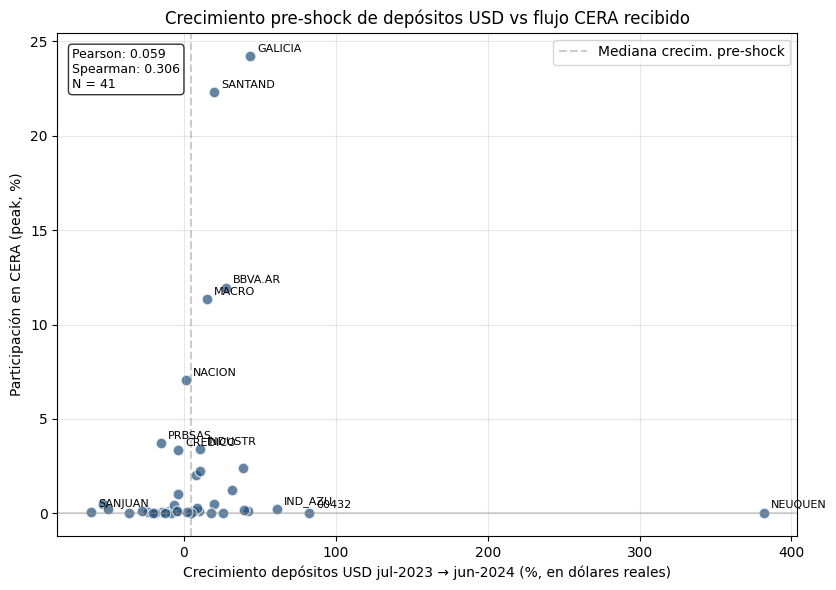

In [19]:
from scipy.stats import pearsonr, spearmanr

fig, ax = plt.subplots(figsize=(8.5, 6))
x = pre_pivot.crec_anual_pct
y = pre_pivot.share_cera * 100

ax.scatter(x, y, s=60, alpha=0.7, color="#1f4e79", edgecolor="white")
for _, row in pre_pivot.iterrows():
    if row.share_cera > 0.03 or abs(row.crec_anual_pct) > 60:
        ax.annotate(str(row.sigla)[:8] if pd.notna(row.sigla) else row.codigo_entidad,
                    (row.crec_anual_pct, row.share_cera * 100),
                    fontsize=8, xytext=(5, 3), textcoords="offset points")

ax.set_xlabel("Crecimiento depósitos USD jul-2023 → jun-2024 (%, en dólares reales)")
ax.set_ylabel("Participación en CERA (peak, %)")
ax.set_title("Crecimiento pre-shock de depósitos USD vs flujo CERA recibido")
ax.grid(alpha=0.3)
ax.axhline(0, color="gray", alpha=0.3)
ax.axvline(pre_pivot.crec_anual_pct.median(), color="gray", ls="--", alpha=0.4, label="Mediana crecim. pre-shock")
ax.legend()

rho_p, _ = pearsonr(x, y)
rho_s, _ = spearmanr(x, y)
ax.text(0.02, 0.97, f"Pearson: {rho_p:.3f}\nSpearman: {rho_s:.3f}\nN = {len(pre_pivot)}",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

## Tendencia agregada por grupo de exposición

Agrupamos los bancos en cuartiles por su participación en CERA peak y graficamos la evolución mensual del stock de depósitos USD total de cada grupo en dólares reales, normalizado a 100 en jun-2024. Si los grupos tenían trayectorias paralelas pre-shock, la identificación gana respaldo.

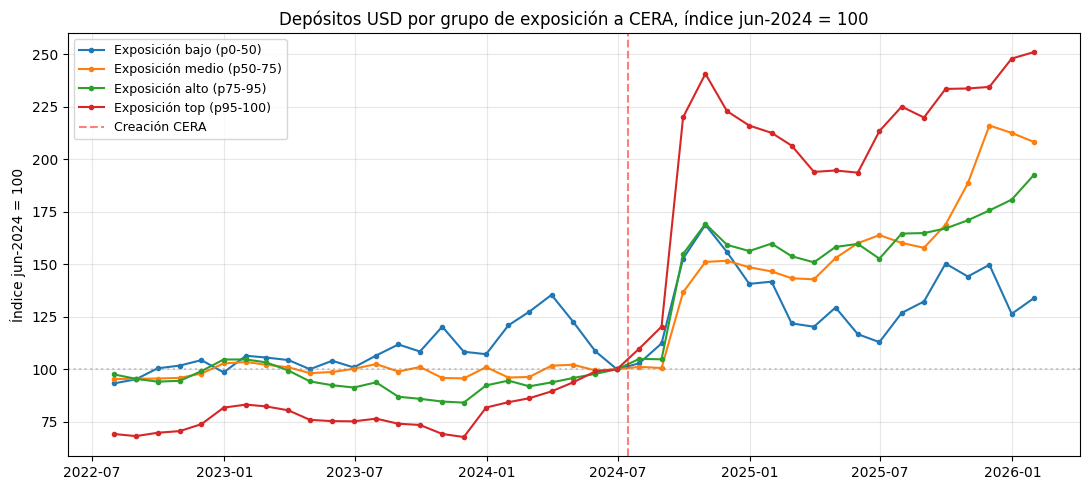

In [20]:
# Cuartiles por share_cera. Cargamos serie mensual completa de depósitos USD por banco.
q = f"""
select p.codigo_entidad, p.yyyymm, abs(sum(p.saldo)) as dep_ars
from '{PANEL_BAL}' p
where (p.codigo_cuenta like '315%' or p.codigo_cuenta like '316%')
  and p.yyyymm between 202207 and 202601
group by p.codigo_entidad, p.yyyymm
"""
serie_bancos = duckdb.sql(q).df()
serie_bancos = serie_bancos.merge(fx_eom, on="yyyymm", how="left")
serie_bancos["dep_usd"] = serie_bancos["dep_ars"] / serie_bancos["tc_a3500"]

# Asigno grupo de exposición
grupos_exposicion = pre_pivot[["codigo_entidad", "share_cera"]].copy()
grupos_exposicion["grupo_exposicion"] = pd.qcut(grupos_exposicion["share_cera"],
    q=[0, 0.5, 0.75, 0.95, 1.0],
    labels=["bajo (p0-50)", "medio (p50-75)", "alto (p75-95)", "top (p95-100)"])

serie_bancos = serie_bancos.merge(grupos_exposicion[["codigo_entidad", "grupo_exposicion"]],
                                   on="codigo_entidad", how="inner")

agreg = (serie_bancos.groupby(["grupo_exposicion", "yyyymm"], observed=True)["dep_usd"]
         .sum().reset_index())

# Normalizo a 100 en jun-2024 por grupo
base = agreg[agreg.yyyymm == 202406].set_index("grupo_exposicion")["dep_usd"]
agreg["indice"] = agreg.apply(lambda r: r.dep_usd / base[r.grupo_exposicion] * 100, axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
for grupo, df_g in agreg.groupby("grupo_exposicion", observed=True):
    df_g = df_g.sort_values("yyyymm")
    fechas = pd.to_datetime(df_g.yyyymm.astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
    ax.plot(fechas, df_g["indice"], marker="o", ms=3, label=f"Exposición {grupo}")

ax.axvline(pd.Timestamp("2024-07-15"), ls="--", color="red", alpha=0.5, label="Creación CERA")
ax.axhline(100, color="gray", ls=":", alpha=0.4)
ax.set_title("Depósitos USD por grupo de exposición a CERA, índice jun-2024 = 100")
ax.set_ylabel("Índice jun-2024 = 100")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Asignación del flujo dentro del balance

Una vez que un banco recibe depósitos ME adicionales, el Régimen de Aplicación de Recursos en Moneda Extranjera del BCRA limita las aplicaciones posibles a cuatro grandes canales del activo:

| Canal | Capítulo | Concepto |
|---|---|---|
| Efectivo y BCRA en ME | 115% | Encaje en ME + efectivo en ME (integración regulatoria) |
| Títulos públicos en ME | 125% | Bonos Tesoro USD + Letras BCRA ME |
| Crédito a SPNF en ME | 135% | Préstamos a empresas exportadoras y sectores generadores de divisas |
| Interbancario ME | 136% | Call, pases activos al BCRA en ME, operaciones entre entidades |

Acá medimos cómo se repartió el shock entre estos cuatro canales, primero a nivel sistema y después por banco. El período comparado es **pre-shock (jun-2024) vs post persistente (ene-2026)**, en dólares reales.

In [21]:
q = f"""
select p.codigo_entidad, p.yyyymm,
       abs(sum(case when p.codigo_cuenta like '115%' then p.saldo else 0 end)) as c115,
       abs(sum(case when p.codigo_cuenta like '125%' then p.saldo else 0 end)) as c125,
       abs(sum(case when p.codigo_cuenta like '135%' then p.saldo else 0 end)) as c135,
       abs(sum(case when p.codigo_cuenta like '136%' then p.saldo else 0 end)) as c136,
       abs(sum(case when p.codigo_cuenta like '315%' or p.codigo_cuenta like '316%' then p.saldo else 0 end)) as dep_usd_pasivo
from '{PANEL_BAL}' p
where p.yyyymm in (202406, 202601)
group by p.codigo_entidad, p.yyyymm
"""
por_banco_canal = duckdb.sql(q).df()
por_banco_canal = por_banco_canal.merge(fx_eom, on="yyyymm", how="left")

# Convierto todo a USD (miles de millones) dividiendo por el TC de cada mes
for c in ["c115", "c125", "c135", "c136", "dep_usd_pasivo"]:
    por_banco_canal[c] = por_banco_canal[c] / por_banco_canal["tc_a3500"] / 1e9

por_banco_canal = por_banco_canal.drop(columns=["tc_a3500"])
por_banco_canal.head()

,codigo_entidad,yyyymm,c115,c125,c135,c136,dep_usd_pasivo
0,00330,202601,0.09,0.02,0.21,0.00,0.30
1,00448,202406,0.00,0.00,0.00,0.00,0.00
2,00448,202601,0.00,0.00,0.00,0.00,0.00
3,44077,202406,0.00,0.00,0.00,0.00,0.00
4,44077,202601,0.00,0.00,0.00,0.00,0.00


## Nivel sistema: ¿a qué canal fue el shock?

Sumo sobre todos los bancos y comparo jun-2024 vs ene-2026.

In [22]:
sistema = por_banco_canal.groupby("yyyymm")[["c115","c125","c135","c136","dep_usd_pasivo"]].sum()
sistema = sistema.T
sistema.columns = [f"jun_2024", "ene_2026"]
sistema["delta_usd_b"] = sistema["ene_2026"] - sistema["jun_2024"]
sistema["delta_pct"] = (sistema["ene_2026"] / sistema["jun_2024"] - 1) * 100
sistema = sistema.rename(index={
    "c115": "Efectivo y BCRA en ME (115)",
    "c125": "Títulos públicos en ME (125)",
    "c135": "Crédito a SPNF en ME (135)",
    "c136": "Interbancario ME (136)",
    "dep_usd_pasivo": "[Depósitos USD SPNF (315+316)]"
})
sistema.round(2)

,jun_2024,ene_2026,delta_usd_b,delta_pct
Efectivo y BCRA en ME (115),12.63,21.84,9.21,72.94
Títulos públicos en ME (125),7.01,3.91,-3.10,-44.18
Crédito a SPNF en ME (135),6.60,20.42,13.82,209.56
Interbancario ME (136),0.35,0.06,-0.28,-81.43
[Depósitos USD SPNF (315+316)],19.98,41.39,21.40,107.11


In [23]:
# Balance sheet identity check: ¿la suma de los 4 canales explica el aumento de depósitos USD?
delta_depositos = sistema.loc["[Depósitos USD SPNF (315+316)]", "delta_usd_b"]
delta_canales = sistema.loc[["Efectivo y BCRA en ME (115)", "Títulos públicos en ME (125)",
                              "Crédito a SPNF en ME (135)", "Interbancario ME (136)"], "delta_usd_b"].sum()
print(f"Δ Depósitos USD del SPNF (jun-2024 → ene-2026):     USD {delta_depositos:,.2f} mil millones")
print(f"Δ suma de los 4 canales ME del activo:             USD {delta_canales:,.2f} mil millones")
print(f"Cobertura:                                         {delta_canales/delta_depositos*100:,.1f}%")
print()
print("Reparto del incremento de depósitos USD entre canales:")
for k, v in sistema.loc[["Efectivo y BCRA en ME (115)", "Títulos públicos en ME (125)",
                          "Crédito a SPNF en ME (135)", "Interbancario ME (136)"], "delta_usd_b"].items():
    print(f"  {k:40s}  {v:+8,.2f} USD B   ({v/delta_depositos*100:+5.1f}% del Δ depósitos)")

Δ Depósitos USD del SPNF (jun-2024 → ene-2026):     USD 21.40 mil millones
Δ suma de los 4 canales ME del activo:             USD 19.66 mil millones
Cobertura:                                         91.8%

Reparto del incremento de depósitos USD entre canales:
  Efectivo y BCRA en ME (115)                  +9.21 USD B   (+43.0% del Δ depósitos)
  Títulos públicos en ME (125)                 -3.10 USD B   (-14.5% del Δ depósitos)
  Crédito a SPNF en ME (135)                  +13.82 USD B   (+64.6% del Δ depósitos)
  Interbancario ME (136)                       -0.28 USD B   ( -1.3% del Δ depósitos)


/var/folders/lb/5gf2mnsn50bc7224k6lkc5480000gn/T/ipykernel_17260/1004797697.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(canales, rotation=15, ha="right", fontsize=9)


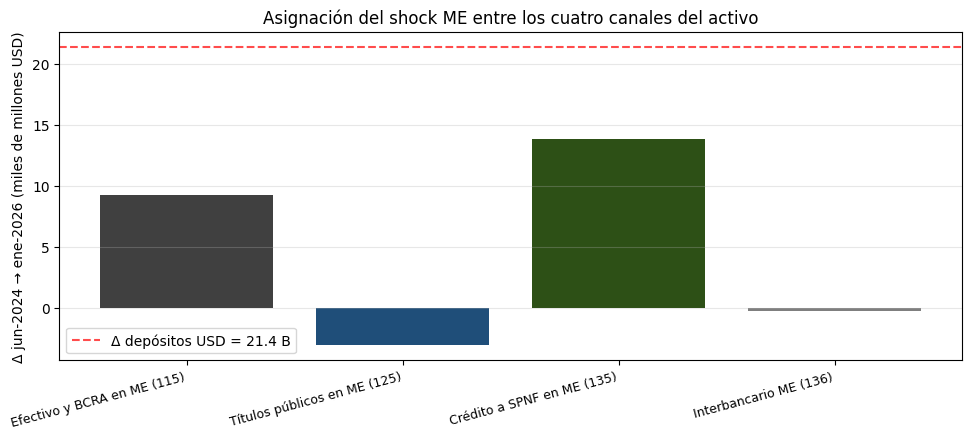

In [24]:
fig, ax = plt.subplots(figsize=(10, 4.5))
canales = ["Efectivo y BCRA en ME (115)", "Títulos públicos en ME (125)",
           "Crédito a SPNF en ME (135)", "Interbancario ME (136)"]
valores = [sistema.loc[c, "delta_usd_b"] for c in canales]
colors = ["#404040", "#1f4e79", "#2d5016", "#7f7f7f"]
ax.bar(canales, valores, color=colors)
ax.axhline(delta_depositos, color="red", ls="--", alpha=0.7, label=f"Δ depósitos USD = {delta_depositos:,.1f} B")
ax.set_ylabel("Δ jun-2024 → ene-2026 (miles de millones USD)")
ax.set_title("Asignación del shock ME entre los cuatro canales del activo")
ax.set_xticklabels(canales, rotation=15, ha="right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Heterogeneidad por banco

La pregunta más sutil: ¿todos los bancos asignaron parecido, o hubo diferencias sistemáticas según el modelo de negocio? Para cada banco con CERA > 0, computo la variación en cada uno de los cuatro canales y grafico contra el shock CERA recibido.

In [25]:
# Δ por banco por canal
wide = por_banco_canal.pivot(index="codigo_entidad", columns="yyyymm", values=["c115","c125","c135","c136"])
wide.columns = [f"{var}_{y}" for var, y in wide.columns]
wide = wide.fillna(0)
for c in ["c115","c125","c135","c136"]:
    wide[f"delta_{c}"] = wide[f"{c}_202601"] - wide[f"{c}_202406"]

# Merge con CERA share
delta_por_banco = wide.reset_index().merge(
    shares[["codigo_entidad", "sigla", "saldo", "share"]].rename(columns={"share": "share_cera"}),
    on="codigo_entidad", how="inner"
)
delta_por_banco["cera_peak_usd_b"] = delta_por_banco["saldo"] / fx_eom.loc[fx_eom.yyyymm == mes_peak_sistema, "tc_a3500"].iloc[0] / 1e9
delta_por_banco = delta_por_banco.sort_values("share_cera", ascending=False)
delta_por_banco[["codigo_entidad", "sigla", "cera_peak_usd_b",
                 "delta_c115", "delta_c125", "delta_c135", "delta_c136"]].head(15).round(2)

,codigo_entidad,sigla,cera_peak_usd_b,delta_c115,delta_c125,delta_c135,delta_c136
0,00007,GALICIA,2.98,3.12,-0.39,3.31,-0.13
12,00072,SANTAND,2.74,0.85,-0.05,1.22,-0.15
4,00017,BBVA.AR,1.47,0.99,-0.28,2.05,-0.01
25,00285,MACRO,1.39,1.10,-0.04,0.90,0.00
1,00011,NACION,0.87,1.14,-1.04,1.66,0.00
2,00014,PRBSAS,0.46,0.03,0.13,0.57,0.00
3,00015,INDUSTR,0.42,0.60,-0.15,1.46,0.00
19,00191,CREDICO,0.41,0.19,-0.35,0.13,0.00
6,00027,SUPERVI,0.29,0.35,-0.02,0.43,0.00
18,00150,NaN,0.28,-0.54,-0.03,-0.38,0.00


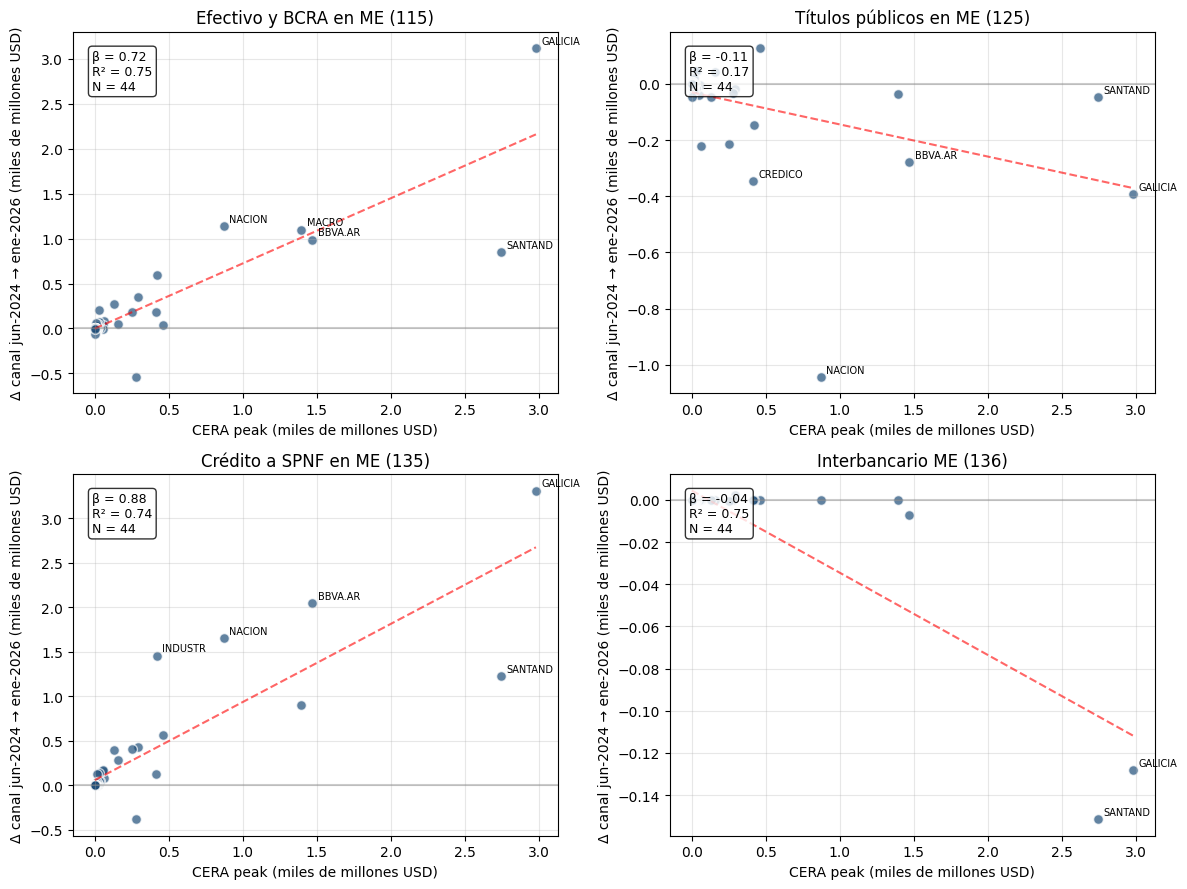

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
canales_cols = [("delta_c115", "Efectivo y BCRA en ME (115)"),
                ("delta_c125", "Títulos públicos en ME (125)"),
                ("delta_c135", "Crédito a SPNF en ME (135)"),
                ("delta_c136", "Interbancario ME (136)")]

from scipy.stats import linregress
for ax, (col, titulo) in zip(axes.flatten(), canales_cols):
    d = delta_por_banco[delta_por_banco.cera_peak_usd_b > 0]
    x = d.cera_peak_usd_b
    y = d[col]
    ax.scatter(x, y, s=50, alpha=0.7, color="#1f4e79", edgecolor="white")
    if len(d) > 2:
        res = linregress(x, y)
        xr = np.linspace(0, x.max(), 50)
        ax.plot(xr, res.slope * xr + res.intercept, ls="--", color="red", alpha=0.6)
        ax.text(0.04, 0.95, f"β = {res.slope:.2f}\nR² = {res.rvalue**2:.2f}\nN = {len(d)}",
                transform=ax.transAxes, fontsize=9, va="top",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    # Etiquetar outliers
    for _, row in d.iterrows():
        if abs(row[col]) > d[col].std() * 1.5 or row.cera_peak_usd_b > 2:
            ax.annotate(str(row.sigla)[:8] if pd.notna(row.sigla) else row.codigo_entidad,
                        (row.cera_peak_usd_b, row[col]), fontsize=7,
                        xytext=(4, 3), textcoords="offset points")

    ax.set_xlabel("CERA peak (miles de millones USD)")
    ax.set_ylabel("Δ canal jun-2024 → ene-2026 (miles de millones USD)")
    ax.set_title(titulo)
    ax.grid(alpha=0.3)
    ax.axhline(0, color="gray", alpha=0.4)

plt.tight_layout()
plt.show()

**Interpretación del coeficiente β**: por cada USD 1B adicional de CERA recibida, el banco aumentó en β miles de millones de USD el saldo del canal. La suma de los cuatro β debería aproximar la unidad si los cuatro canales absorben completamente el shock (balance sheet identity); desvíos vienen de otros pasivos ME compensadores, crecimiento de activos no considerados, y reclasificaciones.

**Lectura regulatoria del +43% a encaje BCRA en ME**. Las CERA están sujetas a las exigencias estándar del régimen de Efectivo Mínimo del BCRA (TO Efectivo Mínimo, sec. 7.5 + 1.3.2.2): al considerarse depósitos a la vista en moneda extranjera, exigen una integración del **25% en cuenta corriente del BCRA** (cuenta 115015). Por lo tanto:

- De los USD 21.4 B de aumento en depósitos USD del SPNF, **USD 5.35 B (25%) son encaje obligatorio mecánico**.
- El residuo entre el encaje observado (+USD 9.21 B, 43% del shock) y el componente obligatorio (USD 5.35 B, 25%) es de **USD 3.86 B (≈18% del shock)**, atribuible a (i) encaje sobre otros depósitos ME que también crecieron en el período, (ii) decisión voluntaria del banco de mantener buffer de liquidez por encima de la exigencia mínima.

Esta descomposición es importante para distinguir el componente regulatorio mecánico del componente discrecional del banco. La parte voluntaria es testeable como respuesta consistente con la hipótesis Diamond-Dybvig (depósitos CERA percibidos como más volátiles → mayor buffer voluntario). Detalles regulatorios completos en `docs/notas/cera_regimen.md` §5.bis.

# Síntesis provisoria

Las observaciones que se desprenden de estas dos secciones, a revisitar cuando se agreguen los pasos siguientes:

- **Magnitud y timing**: (completar al ejecutar — confirmar que el peak cae en sep-oct 2024 con ≈USD 12B, consistente con el dato público de ≈USD 20B declarados y la tasa de permanencia en CERA).
- **Dominancia de la cuenta 315794**: la cuenta USD residentes país es la que absorbe la mayor parte del flujo; las otras tres son marginales.
- **Concentración**: (revisar HHI y share top-k; si el top-5 supera el 75%, la estrategia cross-sectional tiene poco margen).
- **Relación con tamaño preexistente**: si la correlación entre share pre-shock y share CERA es alta (>0.85), el shock es aproximadamente proporcional y la estrategia shift-share tiene sentido. Si es baja, hay que entender qué características del banco predicen la desviación.

**Próximos pasos** a agregar a este mismo notebook como nuevas secciones de nivel H1:

- Pre-tendencias de crecimiento de depósitos USD antes del blanqueo (sección 4).
- Asignación del flujo CERA dentro del balance: crédito vs Tesoro vs BCRA vs interbancario (sección 5).
- Restricciones regulatorias binding ex-ante: PGNME proxy y tope aplicaciones ME (sección 6).
- Construcción del instrumento shift-share a la Bartik (sección 7).